In [397]:
import pandas as pd 
import numpy as np

In [398]:
df = pd.read_csv("../Data/Housing_2.csv")
df["price"] = df["price"]/1000000
housing_data = df
housing_data

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13.30000,7420,4,2,3,1,0,0,0,1,2,1,1.0
1,12.25000,8960,4,4,4,1,0,0,0,1,3,0,1.0
2,12.25000,9960,3,2,2,1,0,1,0,0,2,1,0.5
3,12.21500,7500,4,2,2,1,0,1,0,1,3,1,1.0
4,11.41000,7420,4,1,2,1,1,1,0,1,2,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1.82000,3000,2,1,1,1,0,1,0,0,2,0,0.0
541,1.76715,2400,3,1,1,0,0,0,0,0,0,0,0.5
542,1.75000,3620,2,1,1,1,0,0,0,0,0,0,0.0
543,1.75000,2910,3,1,1,0,0,0,0,0,0,0,1.0


In [399]:
df.isna().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [400]:
from sklearn.model_selection import train_test_split

In [401]:
X = df.drop("price", axis=1)
y = df["price"]

In [402]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2,random_state=32)

In [403]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import root_mean_squared_error
import matplotlib.pyplot as plt

In [404]:
rmse_train = []
rmse_test = []
list_k = []

for i in range(1,40) :
    dt = DecisionTreeRegressor(random_state=32,max_depth=i)
    dt.fit(X_train, y_train)
    y_pred_test = dt.predict(X_test)
    y_pred_train = dt.predict(X_train)
    list_k.append(i)
    rmse_test.append(root_mean_squared_error(y_test,y_pred_test))
    rmse_train.append(root_mean_squared_error(y_train,y_pred_train))

In [405]:
result_df = pd.DataFrame({"x":list_k,"train": rmse_train,"test": rmse_test})

In [406]:
#from sklearn.tree import plot_tree

#plt.figure(figsize=(40, 20))
#plot_tree(dt, feature_names=list(X.columns), filled=True)
#plt.show()

<Axes: xlabel='x'>

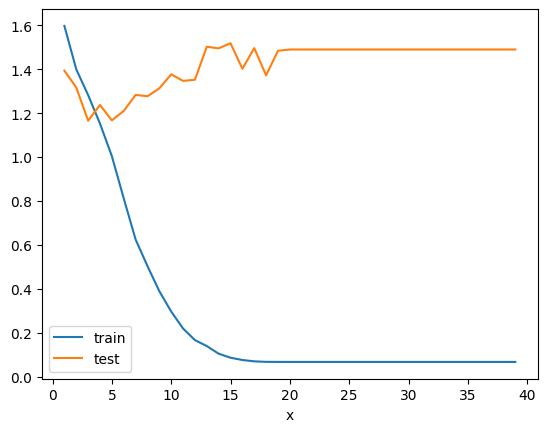

In [407]:
result_df.plot(x= "x")


In [408]:
result_df

,x,train,test
0,1,1.597292,1.393406
1,2,1.399794,1.316671
2,3,1.282288,1.165654
3,4,1.152446,1.237270
4,5,1.004152,1.167241
5,6,0.811936,1.210087
6,7,0.624791,1.283032
7,8,0.503553,1.276984
8,9,0.389192,1.312947
9,10,0.296474,1.376923


In [409]:
%pip install plotly

Note: you may need to restart the kernel to use updated packages.


In [410]:
import plotly.express as px

In [411]:
fig = px.line(result_df,x="x",y=["train","test"], markers=True, title = "RMSE train vs Test",labels={"x":"Max depth","value" : "RMSE"})
fig.update_layout(hovermode = "x unified")

In [412]:
fig = px.bar(result_df,x="x",y=["train","test"], title = "RMSE train vs Test",labels={"x":"Max depth","value" : "RMSE"})
fig.update_layout(hovermode = "x unified")

In [413]:
fig = px.scatter(result_df,x="x",y=["train","test"], title = "RMSE train vs Test",labels={"x":"Max depth","value" : "RMSE"})
fig.update_layout(hovermode = "x unified")

In [414]:
df_long = result_df.melt(id_vars="x",value_vars=["train","test"],var_name="split",value_name="RMSE")

In [415]:
df_long

,x,split,RMSE
0,1,train,1.597292
1,2,train,1.399794
2,3,train,1.282288
3,4,train,1.152446
4,5,train,1.004152
...,...,...,...
73,35,test,1.489913
74,36,test,1.489913
75,37,test,1.489913
76,38,test,1.489913


In [416]:
px.line(df_long,x="x",y = "RMSE",color="split").show()

In [417]:
import seaborn as sns 
import matplotlib.pyplot as plt

<Axes: xlabel='price', ylabel='Count'>

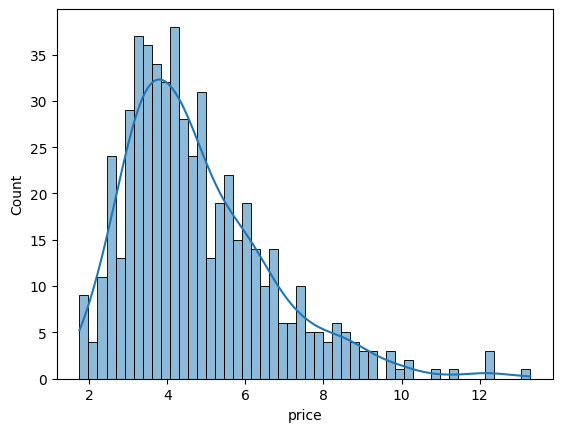

In [418]:
sns.histplot(df["price"],bins=50,kde=True)

<Axes: xlabel='price'>

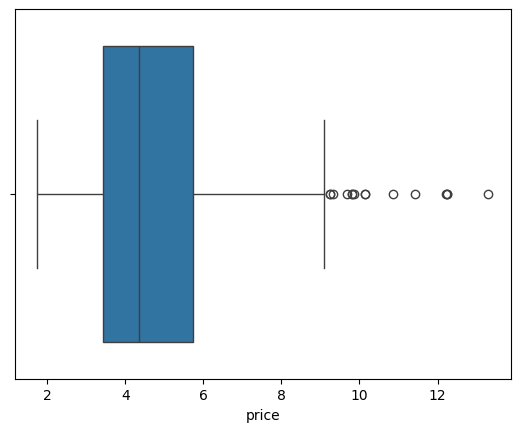

In [419]:
sns.boxplot(x = df["price"])

In [420]:

dt = DecisionTreeRegressor(random_state=32)
dt.fit(X_train, y_train)
y_pred_test = dt.predict(X_test)
y_pred_train = dt.predict(X_train)
rmse_test = root_mean_squared_error(y_test,y_pred_test)
rmse_train = root_mean_squared_error(y_train,y_pred_train)

In [421]:
rmse_train

0.06692662523344214

In [422]:
rmse_test

1.4899126169576942

In [423]:
print(f"depth {dt.get_depth()} N leave: {dt.get_n_leaves()}")

depth 20 N leave: 422


In [424]:
path = dt.cost_complexity_pruning_path(X_train,y_train)

In [425]:
ccp_alpha = path.ccp_alphas

In [429]:
rmse_test = []
rmse_train = []
list_k = []
k=0
for alpha in ccp_alpha : 
    dt = DecisionTreeRegressor(random_state=32, ccp_alpha=alpha)
    dt.fit(X_train,y_train)
    y_pred_test = dt.predict(X_test)
    y_pred_train = dt.predict(X_train)
    list_k.append(k)
    k = k +1 
    rmse_test.append(root_mean_squared_error(y_test,y_pred_test))
    rmse_train.append(root_mean_squared_error(y_train,y_pred_train))

In [430]:
result_df = pd.DataFrame({"x":list_k,"train": rmse_train,"test": rmse_test})

In [431]:
px.line(result_df,x="x",y=["train","test"])